# J-lens vs handwritten logit lens — architecture-independent dataset evaluation

The full dataset analysis from `logit_lens_dataset.ipynb`, using the original **`jlens.LensModel`**
interface and **`jlens.from_hf` / `HFLensModel`** adapter. Change `MODEL_ID` to experiment with
supported HuggingFace causal models; no GPT-2 wrapper or private model members are used here.

The logit lens remains explicit handwritten code below: record raw block outputs and run
`model.unembed(h_l)`. The J-lens transports those **same activations** with `J_l` before
unembedding. Dataset evaluation performs one model forward per prompt. All metrics, controls,
plots, model correctness, and paired inner-layer comparisons are retained.

The default is [Qwen2.5-0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B), a base completion model.
Another small option is [Qwen2.5-1.5B](https://huggingface.co/Qwen/Qwen2.5-1.5B).
Dataset prompts are evaluated as raw text completions; the notebook does not insert chat templates.

**Protocol** (`data/evaluations/README.md`):

* **readout position** — one token per prompt: the last prompt token (the one right before `target`,
  the closing period, the tail of the typo); for poetry — the newline at the end of the first line;
* **rank** — 1-based rank of a word among all tokens in the model’s vocabulary at that position, min over its single-token
  spellings (with/without leading space, case); for order-ops — min over the synonym set
  (numbers → digits and words, operations → symbols and words); multi-token words fall back to their first token;
* **pass@k** — mean over items of the fraction of `intermediates` whose min-over-layers rank ≤ k;
* **control** — the same ranks for the intermediates of *another* item of the same dataset.
  It is the chance level: a lens that surfaces any vaguely topical word scores here too.

**Tokenizer handling:** word spellings use `add_special_tokens=False`; fallback ranks use the
first lexical token, rather than an automatically inserted BOS. Agreement, copy rate, and KL
include all non-special prompt positions, including position 0 when there is no BOS. Vocabulary
size and layer count come from the chosen model. Ranks across different models need care because
their vocabularies and token segmentation differ.


## Setup

In [ ]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# ноутбук открыт из клона репозитория (notebooks/<lens>/) — ищем его корень выше по дереву
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "evaluation.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

Cloning into '/content/jacobian-lens-gpt2'...
remote: Enumerating objects: 253, done.
remote: Counting objects: 100% (215/215), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 253 (delta 96), reused 154 (delta 54), pack-reused 38 (from 1)
Receiving objects: 100% (253/253), 7.00 MiB | 27.57 MiB/s, done.
Resolving deltas: 100% (98/98), done.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens import ActivationRecorder, HFLensModel, LensModel
from jlens.evaluation import (
    DATASETS,
    FIT_MIX,
    ROLE_NAMES,
    evaluate_paired,
    first_layer,
    fit_with_progress,
    identity_lens,
    layer_hit_rate,
    layer_mean,
    layer_median_rank,
    load_eval,
    load_fit_prompts,
    pass_at_k,
    plot_layer_curves,
    shown_layers,
)
from jlens.sharded_fitting import benchmark_dim_batches

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 240)

In [ ]:
!wget https://huggingface.co/neuronpedia/jacobian-lens/resolve/main/qwen3.5-9b-pt/jlens/Salesforce-wikitext/Qwen3.5-9B-Base_jacobian_lens.pt

--2026-10-08 10:00:45--  https://huggingface.co/neuronpedia/jacobian-lens/resolve/main/qwen3.5-9b-pt/jlens/Salesforce-wikitext/Qwen3.5-9B-Base_jacobian_lens.pt
Resolving huggingface.co (huggingface.co)... 18.239.50.103, 18.239.50.16, 18.239.50.49, ...
Connecting to huggingface.co (huggingface.co)|18.239.50.103|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/6a32e94f37ce0052330ad9bb/b2f245a925414bfa3a1547209e3ce60de97ca8b0aed93235ab566a8dfbca1f2f?X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27Qwen3.5-9B-Base_jacobian_lens.pt%3B+filename%3D%22Qwen3.5-9B-Base_jacobian_lens.pt%22%3B&user_id=public&xip=x-YTpxqmTtM&Expires=1791457246&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNmEzMmU5NGYzN2NlMDA1MjMzMGFkOWJiL2IyZjI0NWE5MjU0MTRiZmEzYTE1NDcyMDllM2NlNjBkZTk3Y2E4YjBhZWQ5MzIzNWFiNTY2YThkZmJjYTFmMmZcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZyZXNwb25zZS1

In [ ]:
MODEL_ID = "Qwen/Qwen3.5-9B-Base"
# Other examples: "Qwen/Qwen2.5-1.5B", "openai-community/gpt2"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32  # portable default for inference and Jacobian fitting

hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model: LensModel = jlens.from_hf(hf_model, tokenizer, compile=False)
assert isinstance(model, HFLensModel)
assert model.n_layers >= 2, "The inner-layer comparison needs at least two layers."
LENS_NAMES = ("logit lens", "J-lens")
LAYER_STRIDE = max(1, model.n_layers // 12)
model

config.json:   0%|          | 0.00/3.13k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/79.7k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 12.8MB            

tokenizer.json: downloading bytes:           |  0.00B            

HFLensModel(Qwen3_5ForCausalLM, n_layers=32, d_model=4096)

In [ ]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}

K = 10
KS = sorted({1, 5, 10, 100, K})
LAST = model.n_layers - 1
{dataset: len(samples) for dataset, samples in evals.items()}

{'multihop': 93,
 'multilingual': 107,
 'order-ops': 55,
 'poetry': 98,
 'association': 102,
 'typo': 96}

## Handwritten logit lens on `LensModel`

`ActivationRecorder` hooks the output of every block **before the final normalization**.
`model.unembed` applies the adapter's final norm, output head, and any logit softcap.
This avoids assuming a particular `hidden_states` convention or normalizing the final output twice.

The paired evaluator calls `handwritten_logit_lens` with activations it has already recorded;
it then reads the J-lens from that same dictionary. The standalone `logit_lens` wrapper is useful
for custom prompts, but is not called separately during dataset evaluation.

In [ ]:
@torch.no_grad()
def handwritten_logit_lens(model: LensModel, activations: dict[int, torch.Tensor]) -> torch.Tensor:
    """[n_layers, seq_len, vocab]: direct readout of every raw block output."""
    logits = []
    for layer in range(model.n_layers):
        residual = activations[layer][0].float()
        logits.append(model.unembed(residual).float())
    return torch.stack(logits)


@torch.no_grad()
def logit_lens(model: LensModel, prompt: str) -> torch.Tensor:
    """One-prompt handwritten logit lens, using only the original jlens interface."""
    with ActivationRecorder(model.layers, at=range(model.n_layers)) as recorder:
        model.forward(model.encode(prompt))
    return handwritten_logit_lens(model, recorder.activations)

### Final-layer check against the HuggingFace model

On one prompt, verify that the handwritten final row is the model's own output. This separate
sanity check runs two forwards; the dataset evaluator below still uses one forward per prompt.

In [ ]:
check_prompt = evals["order-ops"][0]["prompt"].rstrip()
with torch.no_grad():
    final_handwritten = logit_lens(model, check_prompt)[-1]
    final_hf = hf_model(input_ids=model.encode(check_prompt), use_cache=False).logits[0].float()
torch.testing.assert_close(final_handwritten, final_hf, rtol=1e-4, atol=1e-5)
print("Handwritten final layer matches the HuggingFace model.")
del final_handwritten, final_hf

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


Handwritten final layer matches the HuggingFace model.


## Load or fit the J-lens

### Persistence, safe resume, and older final lenses
In Colab, `USE_GOOGLE_DRIVE=True` mounts Drive and uses `MyDrive/jacobian-lens-runs`.
Outside Colab, local storage is `~/jacobian-lens-runs`; change `LOCAL_ROOT` as needed.
A failed mount stops instead of silently saving to ephemeral storage. Disabling Drive is
an explicit local-storage opt-in. Paths include full model ID, actual dtype, sequence limit,
run label, and a configuration hash. Keep each entire run directory together; no concurrent writers.

**Existing final lenses need no refit.** A managed final is loaded only after checking its
manifest and ordered-corpus SHA-256, and skips downloads, calibration, and fitting.
For older files set `EXISTING_LENS_PATH = Path('/absolute/path/to/previous/lens.pt')` below,
then rerun the configuration and load/fit cells. This is an **UNVERIFIED legacy opt-in**:
only width/layer coverage are checked, not model identity or fitting provenance. Use a final
lens, never a resumable checkpoint. Old fp16-rounded files remain loadable; precision lost
in an old save cannot be recovered. Do not rewrite old manifests.

The original `REPO_DIR/lens_checkpoints/MODEL_ID.replace('/', '__')/lens.pt` and older
Drive paths under `MyDrive/jacobian-lens` are checked. A recognized candidate **stops a new
fit and prints the exact `EXISTING_LENS_PATH = Path(...)` opt-in**, without loading it.
For example, the earlier flat Drive name is `<model-basename>_jacobian_lens_dataset.pt`.
Custom paths and other configuration-hashed runs are not searched recursively: specify
their final path explicitly. To intentionally fit despite recognized legacy files, set
`ALLOW_NEW_FIT_WITH_LEGACY=True`. This never bypasses managed provenance checks.

Otherwise, the exact ordered `(source, text)` corpus is saved before fitting and reused
without downloading on resume. Configuration/corpus mismatches and checkpoints missing
sidecars are rejected. These safeguards do not hash model weights or fully fingerprint
tokenizer contents; pin model/corpus revisions and do not transplant checkpoints or edit
sidecars. `fit()` alone does not validate all of this provenance. Change `RUN_LABEL` for a
fresh corpus/run. Check source counts: unavailable streaming sources may be skipped.
Task evaluation prompts must never be fitting data.

### One existing model, one device, measured batch selection
This notebook recommends a single worker on the **already loaded generic model**. It does
not spawn extra model copies, switch architectures, enable TF32, or silently change `DTYPE`.
Mixed-device/dtype configurations are rejected. The default remains explicit fp32; an
intentional supported reduced dtype is retained for inference, calibration, and fitting.
Fitting rejects active autocast. Rerun configuration after deliberate model/dtype/math/fit
changes; stale state is rejected before managed load/resume/fit. Managed HF provenance
requires `HFLensModel/from_hf` (custom `Layout` supported), not an arbitrary `LensModel`.
The adapter must retain the current HF root, decoder, blocks, embedding, norm, and head;
after replacing these modules, rebuild the adapter before rerunning configuration.

`DIM_BATCH=None` times complete Jacobians on the longest and median valid prompts in the
saved actual corpus, using actual tokenization/truncation. The fastest summed time across
both prompts is used **directly by fitting**, excluding OOMs and CUDA peaks leaving less
than max(2 GiB, 15% total memory) headroom, accounting for other processes. No measured safe
candidate means stop, not an unmeasured fallback. CPU has no memory estimator. Measurements
and selection are saved; unfinished resumes recalibrate on current hardware. Timing is noisy:
this is not an OOM or speed/ETA guarantee. Larger batches reduce backward passes, not total
work proportionally. An explicit positive `DIM_BATCH` bypasses calibration at your own risk.
There is no separate worker batch override. Final lenses are saved **fp32** via a temporary
file, independent of model dtype. Checkpoints every five prompts can repeat an unsaved tail.


In [ ]:
from jlens.notebook_setup import (
    DatasetFitRun, legacy_final_candidates, persistence_root, runtime_metadata,
)

USE_GOOGLE_DRIVE = False
LOCAL_ROOT = Path.home() / 'jacobian-lens-runs'
EXISTING_LENS_PATH = "Qwen3.5-9B-Base_jacobian_lens.pt"  # Explicit opt-in: a matching older FINAL lens, not a checkpoint.
ALLOW_NEW_FIT_WITH_LEGACY = False  # True only to intentionally ignore discovered old finals.
RUN_LABEL = 'dataset-v1'
FIT_FRACTION = 0.25
FIT_SEED = 0
MAX_SEQ_LEN = 128
DIM_BATCH = None  # Fastest measured safe batch; or a positive manual override.
DIM_BATCH_CANDIDATES = (4, 8, 16, 32)
MEMORY_HEADROOM_FRACTION = 0.15
MEMORY_HEADROOM_GIB = 2.0
CHECKPOINT_EVERY = 5

def current_fit_config():
    return {
        **runtime_metadata(model, hf_model, MODEL_ID, DTYPE, DEVICE),
        'max_seq_len': MAX_SEQ_LEN, 'skip_first': 16,
        'fit_mix': {s: max(1, round(n * FIT_FRACTION)) for s, n in FIT_MIX.items()},
        'fit_fraction': FIT_FRACTION, 'seed': FIT_SEED, 'run_label': RUN_LABEL,
        'checkpoint_every': CHECKPOINT_EVERY,
        'dim_batch_requested': DIM_BATCH, 'candidates': list(DIM_BATCH_CANDIDATES),
        'headroom_fraction': MEMORY_HEADROOM_FRACTION, 'headroom_GiB': MEMORY_HEADROOM_GIB,
    }

FIT_CONFIG = current_fit_config()
configured_objects = (model, hf_model, model.tokenizer)
PERSIST_ROOT = persistence_root(USE_GOOGLE_DRIVE, LOCAL_ROOT)
fit_run = DatasetFitRun(PERSIST_ROOT, FIT_CONFIG)
RUN_DIR = fit_run.directory
LENS_PATH = Path(EXISTING_LENS_PATH).expanduser() if EXISTING_LENS_PATH else fit_run.lens_path
CHECKPOINT_PATH, PROMPTS_PATH = fit_run.checkpoint_path, fit_run.prompts_path
MANIFEST_PATH, BENCHMARK_PATH = fit_run.manifest_path, fit_run.benchmark_path
fit_run.print_paths()
if EXISTING_LENS_PATH is not None:
    print('Explicit unverified final override:', LENS_PATH)

Using local persistence (ephemeral if this is a Colab runtime).
Final lens: /root/jacobian-lens-runs/Qwen--Qwen3.5-9B-Base_float32_seq128_dataset-v1_8b891c115cae/lens.pt
Resume checkpoint: /root/jacobian-lens-runs/Qwen--Qwen3.5-9B-Base_float32_seq128_dataset-v1_8b891c115cae/fit_checkpoint.pt
Ordered corpus: /root/jacobian-lens-runs/Qwen--Qwen3.5-9B-Base_float32_seq128_dataset-v1_8b891c115cae/ordered_prompts.json
Manifest: /root/jacobian-lens-runs/Qwen--Qwen3.5-9B-Base_float32_seq128_dataset-v1_8b891c115cae/manifest.json
Batch measurements: /root/jacobian-lens-runs/Qwen--Qwen3.5-9B-Base_float32_seq128_dataset-v1_8b891c115cae/batch_selection.json
Explicit unverified final override: Qwen3.5-9B-Base_jacobian_lens.pt


In [ ]:
fitted_lens = None  # Never retain a stale result after an interrupted/failed rerun.
if any(old is not new for old, new in zip(configured_objects, (model, hf_model, model.tokenizer))):
    raise RuntimeError('Model/tokenizer replaced; rerun configuration cell after reloading consistently.')
fitted_lens = fit_run.load_or_fit(
    model, current_fit_config(), load_prompts=load_fit_prompts, fit=fit_with_progress,
    benchmark=benchmark_dim_batches, display=display, existing_path=EXISTING_LENS_PATH,
    legacy_candidates=legacy_final_candidates(Path(REPO_DIR), MODEL_ID),
    allow_new_fit=ALLOW_NEW_FIT_WITH_LEGACY,
)
fitted_lens

UNVERIFIED legacy lens: Qwen3.5-9B-Base_jacobian_lens.pt; skipping downloads, benchmark, and fit.


JacobianLens(d_model=4096, n_prompts=458, source_layers=[0..30] (31 layers))

### Identity sanity check

With `J_l = I`, both readouts must produce the same ranks, best layers, top-1 tokens,
agreement, copy rate, and KL. This small check uses the same paired evaluator as the full run.
TF32 and autocast are disabled only within this **exact** assertion, restored even if it fails.
The configured model dtype is unchanged: both paths use the same adapter unembedding;
identity transport operates on fp32 residuals. No silent weight casting or relaxed assertion.

In [ ]:
sanity_evals = {"order-ops": evals["order-ops"][:2]}
from jlens.notebook_setup import strict_identity_precision

with strict_identity_precision(model.input_device.type):
    sanity_words, sanity_items = evaluate_paired(model, identity_lens(model), sanity_evals, desc='identity check', logit_readout=handwritten_logit_lens)
    for frame in (sanity_words, sanity_items):
        left = frame[frame.lens == 'logit lens'].drop(columns='lens').reset_index(drop=True)
        right = frame[frame.lens == 'J-lens'].drop(columns='lens').reset_index(drop=True)
        pd.testing.assert_frame_equal(left, right, check_exact=True)
del sanity_words, sanity_items
print("Identity lens: all metrics match.")

identity check:   0%|          | 0/1 [00:00<?, ?it/s]

order-ops:   0%|          | 0/2 [00:00<?, ?it/s]

Identity lens: all metrics match.


## 1. Run

`words` — a row per (lens, item, word) with the rank at every layer; `items` — a row per
(lens, item) with the model answer, readout top-1 tokens, and per-layer statistics over all
prompt positions. `evaluate_paired` records activations once per prompt and reads each lens
sequentially, releasing vocabulary logits after collecting its metrics. It does not cache
activations or logits across the dataset.

In [12]:
words, items = evaluate_paired(model, fitted_lens, evals, logit_readout=handwritten_logit_lens)
words["inner_best"] = [int(r[:-1].min()) for r in words.ranks]
words["inner_best_layer"] = [int(r[:-1].argmin()) for r in words.ranks]

# The final row and model answers must agree for every paired item/word.
word_keys = ["dataset", "item", "kind", "word", "role"]
final_ranks = words.assign(final_rank=[int(r[-1]) for r in words.ranks]).pivot(
    index=word_keys, columns="lens", values="final_rank"
)
assert (final_ranks["logit lens"] == final_ranks["J-lens"]).all()
for column in ("model_top1", "model_correct", "readout_token"):
    paired = items.pivot(index=["dataset", "item"], columns="lens", values=column)
    pd.testing.assert_series_equal(paired["logit lens"], paired["J-lens"], check_names=False)
for name in LENS_NAMES:
    frame = items[items.lens == name]
    np.testing.assert_allclose(np.stack(frame.agreement)[:, -1], 1)
    np.testing.assert_allclose(np.stack(frame.kl_to_final)[:, -1], 0, atol=1e-6)
print("Final model readout matches for both lenses.")

paired lenses:   0%|          | 0/6 [00:00<?, ?it/s]

multihop:   0%|          | 0/93 [00:00<?, ?it/s]

multilingual:   0%|          | 0/107 [00:00<?, ?it/s]

order-ops:   0%|          | 0/55 [00:00<?, ?it/s]

poetry:   0%|          | 0/98 [00:00<?, ?it/s]

association:   0%|          | 0/102 [00:00<?, ?it/s]

typo:   0%|          | 0/96 [00:00<?, ?it/s]

Final model readout matches for both lenses.


In [13]:
words.head()

,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens,inner_best,inner_best_layer
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[22266, 31426, 33812, 33931, 36083, 39641, 727...",119,31,logit lens,1110,30
1,multihop,carnival-ocean,control,China,0,True,False,"[19769, 19220, 23097, 19172, 13942, 15087, 876...",501,31,logit lens,2595,30
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[16381, 17135, 20720, 16031, 20309, 31967, 377...",1,23,logit lens,1,23
3,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[133881, 60851, 39871, 15898, 15624, 7199, 181...",119,31,J-lens,184,27
4,multihop,carnival-ocean,control,China,0,True,False,"[70265, 14285, 11612, 383, 1419, 1916, 1473, 8...",383,3,J-lens,383,3


In [14]:
items.head()

,dataset,item,prompt,target,readout_token,model_top1,model_correct,readout_top1,agreement,copy_rate,kl_to_final,lens
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,Atlantic,True,"[ , , , , , , 陆, 陆, b, R, �, , **, **...","[0.055555556, 0.055555556, 0.0, 0.055555556, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[6.3537164, 6.2880206, 6.455623, 6.120061, 6.0...",logit lens
1,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,Atlantic,True,"[ […], […], –, 。, <|endoftext|>, <|endoftext...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.16666667, 0.11111111, 0.2222...","[18.36731, 18.61497, 17.092546, 8.744767, 13.9...",J-lens
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,Portuguese,True,"[ , , ..., , ..., , ..., ..., ..., ..., ......","[0.071428575, 0.071428575, 0.0, 0.071428575, 0...","[0.0, 0.0, 0.0, 0.071428575, 0.0, 0.071428575,...","[5.740849, 5.6479573, 5.8026934, 5.4446816, 5....",logit lens
3,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,Portuguese,True,"[ […], <|endoftext|>, […], 。, <|endoftext|>,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.071428575, 0.0, 0.071428575,...","[17.932045, 18.256714, 18.32916, 9.530673, 13....",J-lens
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,is,blue,False,"[ , , , , , , color, color, color, ug, (...","[0.083333336, 0.083333336, 0.0, 0.083333336, 0...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[6.191494, 6.111171, 6.348797, 6.095241, 5.874...",logit lens


In [15]:
inter = words[words.kind == "intermediate"]
control = words[words.kind == "control"]
target = words[words.kind == "target"]

## 2. Can the selected model solve the tasks at all?

The lens can only show an intermediate step the model actually computes. For the three sets with a `target`,
check whether the model's own top-1 at the readout position is the target.

In [16]:
model_items = items.drop_duplicates(["dataset", "item"])
with_target = model_items.dropna(subset=["model_correct"]).astype({"model_correct": bool})
accuracy = with_target.groupby("dataset").model_correct.mean()
accuracy.to_frame("model top-1 == target")

,model top-1 == target
dataset,
multihop,0.397849
multilingual,0.261682
order-ops,0.145455


In [17]:
with_target.groupby("dataset").head(6)[["dataset", "item", "prompt", "target", "model_top1", "model_correct"]]

,dataset,item,prompt,target,model_top1,model_correct
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,Atlantic,True
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,Portuguese,True
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,blue,False
6,multihop,spider-legs,Fact: The number of legs on the animal that sp...,8,,False
8,multihop,basketball-players,Fact: The number of players per side in the sp...,5,,False
10,multihop,paper-continent,Fact: The continent where the country that inv...,Asia,Asia,True
186,multilingual,spanish-opposite-big,"Lo opuesto de ""grande"" es """,pequeño,pe,False
188,multilingual,french-season-summer,La saison après l'été est l',automne,automne,True
190,multilingual,german-opposite-loud,Das Gegenteil von laut ist,leise,le,True
192,multilingual,chinese-color-banana,"""香蕉""的颜色是""",黄,黄色,False


## 3. pass@k: intermediates vs control vs target

In [18]:
scores = pass_at_k(words, ks=KS)
scores.pivot_table(index="dataset", columns=["kind", "k", "lens"], values="score").round(3)

kind         control                                                                  intermediate                                                                  target                                                                 
k                1                 5                 10                100                     1                 5                 10                100               1                 5                 10                100           
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens       J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                                                                                                                                                                                    
association    0.000      0.000  0.010      0.000  0.010      0.000  0.039      0.000        0.010      0.000  0.039      0.000  0.078      0.010  0.333      0.245    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
multihop       0.033      0.098  0.054      0.141  0.076      0.174  0.239      0.275        0.151      0.183  0.317      0.382  0.452      0.446  0.785      0.824  0.527      0.516  0.677      0.656  0.699      0.753  0.839      0.968
multilingual   0.000      0.000  0.003      0.000  0.012      0.003  0.060      0.025        0.301      0.168  0.451      0.318  0.491      0.393  0.645      0.610  0.523      0.551  0.794      0.850  0.832      0.879  0.972      0.972
order-ops      0.020      0.010  0.100      0.150  0.220      0.380  0.450      0.760        0.036      0.091  0.255      0.300  0.373      0.518  0.773      0.927  0.036      0.055  0.164      0.200  0.200      0.418  0.473      0.709
poetry         0.000      0.000  0.000      0.000  0.000      0.000  0.082      0.031        0.010      0.000  0.010      0.010  0.061      0.010  0.224      0.163    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
typo           0.000      0.000  0.000      0.000  0.000      0.000  0.031      0.042        0.229      0.396  0.448      0.573  0.573      0.646  0.865      0.896    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN

The min over layers includes the last row — the model's own output. Split it: what do the inner layers (all but the last)
show that the output does not?

In [19]:
inner = pass_at_k(words, ks=KS, layers=slice(None, -1)).assign(readout=f"layers 0..{LAST - 1}")
output = pass_at_k(words, ks=KS, layers=[LAST]).assign(readout="model output")
split = pd.concat([inner, output], ignore_index=True)
split[split.k == K].pivot_table(index="dataset", columns=["kind", "readout", "lens"], values="score").round(3)

kind              control                                    intermediate                                          target                                   
readout      layers 0..30            model output            layers 0..30            model output            layers 0..30            model output           
lens               J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens
dataset                                                                                                                                                     
association         0.010      0.000        0.000      0.000        0.078      0.010        0.000      0.000          NaN        NaN          NaN        NaN
multihop            0.054      0.174        0.065      0.065        0.387      0.435        0.296      0.296        0.688      0.753        0.656      0.656
multilingual        0.012      0.003        0.000      0.000        0.491      0.393        0.044      0.044        0.822      0.869        0.411      0.411
order-ops           0.190      0.380        0.050      0.050        0.300      0.518        0.136      0.136        0.200      0.418        0.091      0.091
poetry              0.000      0.000        0.000      0.000        0.061      0.010        0.000      0.000          NaN        NaN          NaN        NaN
typo                0.000      0.000        0.000      0.000        0.573      0.646        0.000      0.000          NaN        NaN          NaN        NaN

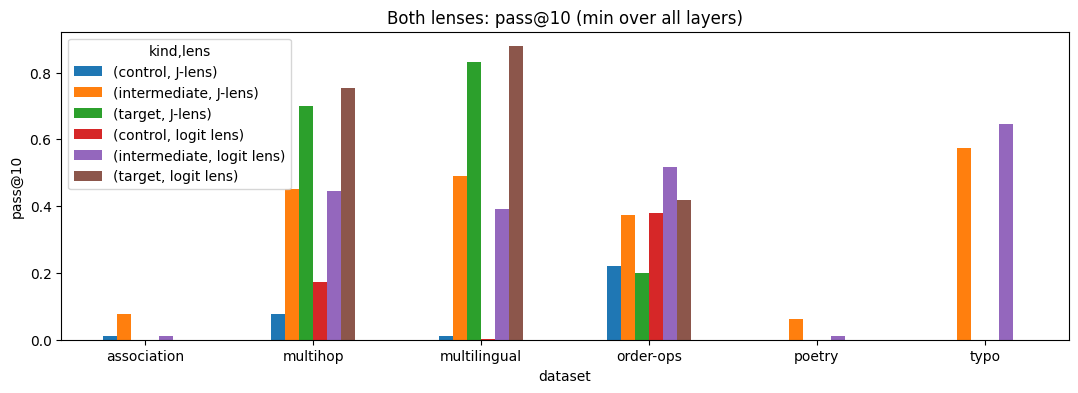

"J-lens − logit lens, inner pass@k",intermediate,control,target
dataset,,,
association,0.069,0.010,NaN
multihop,-0.048,-0.120,-0.065
multilingual,0.098,0.009,-0.047
order-ops,-0.218,-0.190,-0.218
poetry,0.051,0.000,NaN
typo,-0.073,0.000,NaN


In [20]:
at_k = scores[scores.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
at_k.plot.bar(figsize=(13, 4), rot=0, title=f"Both lenses: pass@{K} (min over all layers)")
plt.ylabel(f"pass@{K}")
plt.show()

inner_at_k = inner[inner.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
output_at_k = output[output.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
inner_delta = pd.DataFrame({
    kind: inner_at_k[(kind, "J-lens")] - inner_at_k[(kind, "logit lens")]
    for kind in ("intermediate", "control", "target")
})
display(inner_delta.rename_axis(columns="J-lens − logit lens, inner pass@k").round(3))

## 4. At what depth do the words surface?

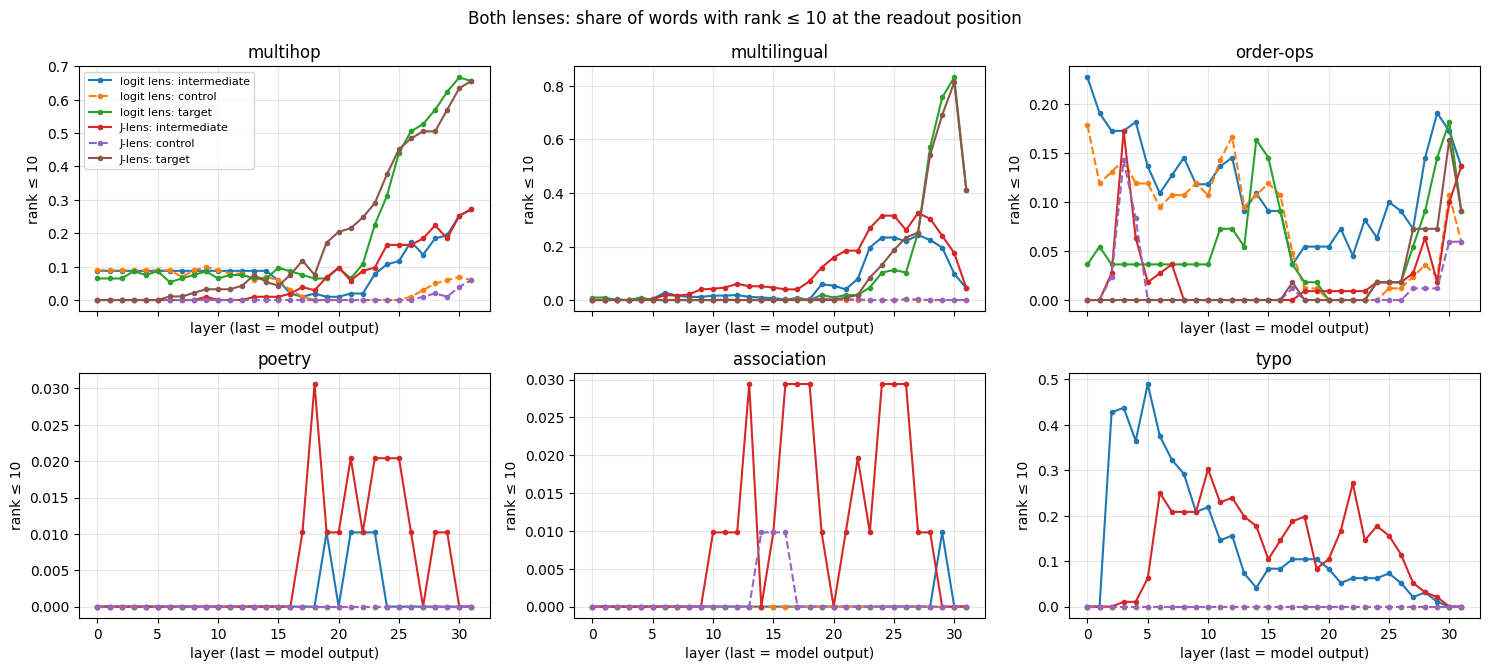

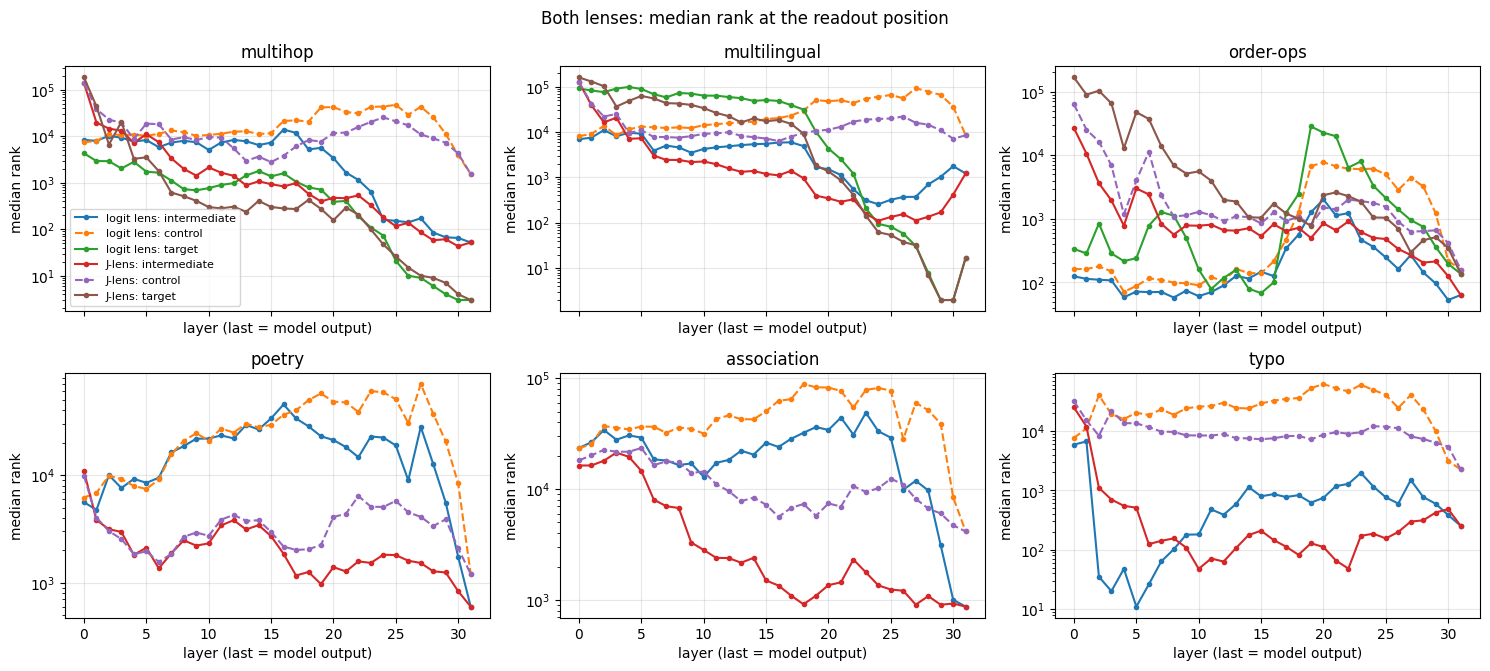

In [21]:
def word_curves(stat):
    return {
        f"{name}: {kind}": stat(words[(words.lens == name) & (words.kind == kind)])
        for name in LENS_NAMES
        for kind in ("intermediate", "control", "target")
    }


plot_layer_curves(
    word_curves(lambda frame: layer_hit_rate(frame, K)),
    title=f"Both lenses: share of words with rank ≤ {K} at the readout position",
    ylabel=f"rank ≤ {K}",
)
plot_layer_curves(
    word_curves(layer_median_rank),
    title="Both lenses: median rank at the readout position",
    ylabel="median rank",
    logy=True,
)

Where the best rank of each intermediate is reached (only words that are hits, rank ≤ K):

In [22]:
(
    inter[inter.best_rank <= K]
    .groupby(["dataset", "lens"]).best_layer.value_counts().unstack(fill_value=0)
    .reindex(columns=range(model.n_layers), fill_value=0)
)

best_layer               0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31
dataset      lens                                                                                                                                      
association  J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   1   1   0   1   0   0   1   0   1   0   0   2   0   0   0   0   0
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0
multihop     J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   2   0   0   2   2   7   4   4   1   2   0   9   9
             logit lens   9   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   1   1   1   1   1   5   1   4   4  10   4
multilingual J-lens       0   0   0   0   0   0   1   1   0   4   2   0   6   0   0   1   3   0   3  14  15  11   7  29  29  23  17  30   8   6   0   0
             logit lens   0   0   1   0   0   0   6   0   2   0   0   2   0   1   0   1   0   0   0   6   4   2   3  39  20  21  13  21  15  10   1   0
order-ops    J-lens       0   0   0  17   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   1   1   5   0   6  10
             logit lens  18   1   1   0   2   0   0   0   0   0   1   2   1   0   1   1   1   0   0   3   1   3   1   3   1   0   0   0   7   3   6   0
poetry       J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   0   0   1   0   1   0   0   0   0   1   0   0   0
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0
typo         J-lens       0   0   0   0   1   0  13   2   1   4   6   0   0   1   0   0   1   1   2   1   1   3   9   1   3   5   0   0   0   0   0   0
             logit lens   0   0  17  16   1  16   4   2   1   1   0   1   0   0   0   0   0   1   0   0   0   0   0   0   1   0   1   0   0   0   0   0

## 5. How both lenses behave in general

Over all prompt positions (not only the readout one):

* **agreement** — the layer's top-1 equals the model's top-1: how deep the final prediction is formed;
* **copy rate** — the layer's top-1 is the input token at that position: the residual stream still "is" the token embedding
  (models with tied embeddings share the input and output token weights, so an untouched embedding decodes to itself);
* **KL(model ‖ layer)** — how far the layer's distribution is from the output one.

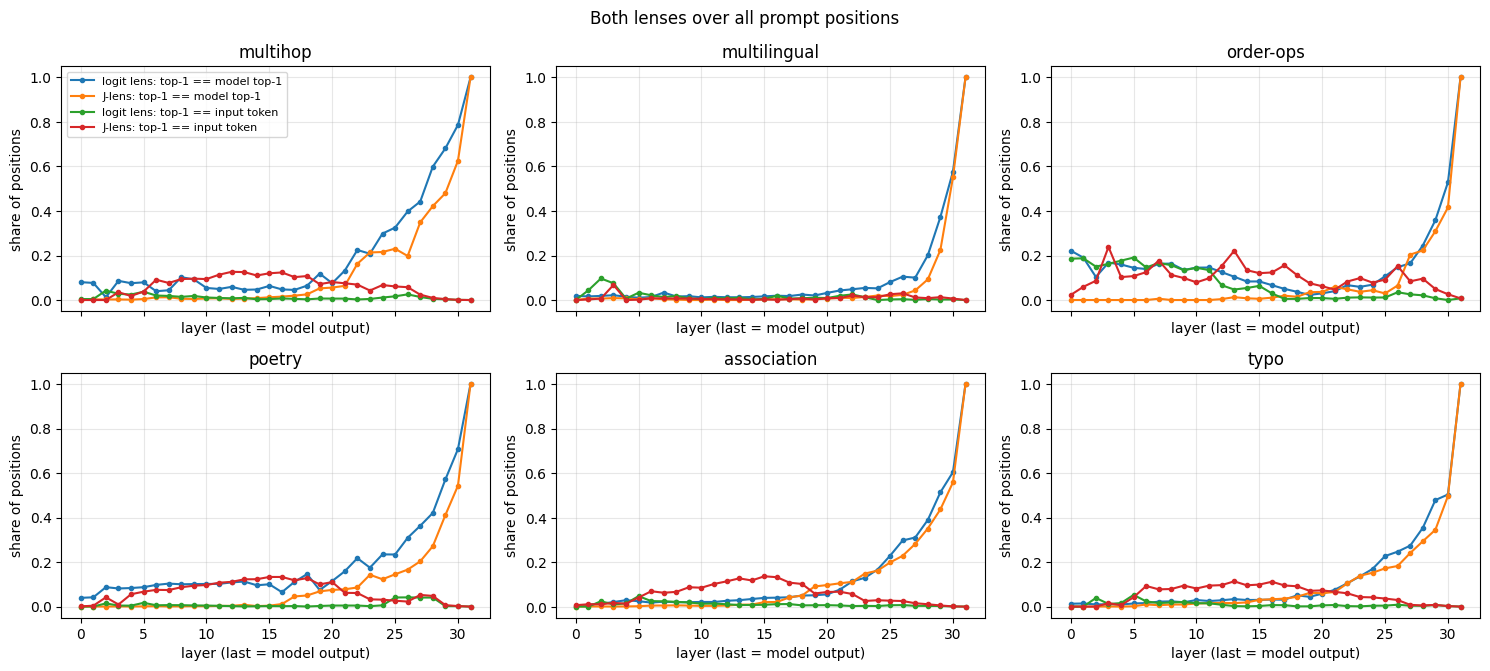

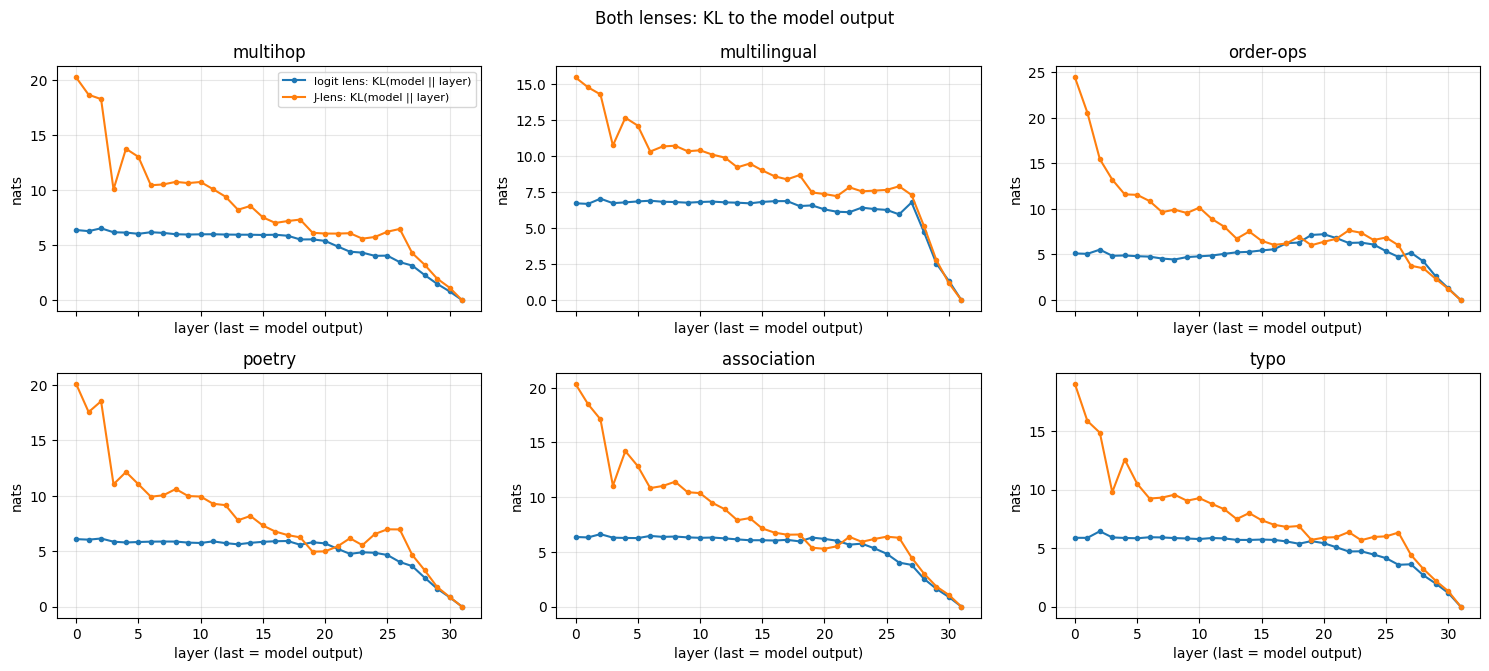

In [23]:
behaviour = {
    name: {column: layer_mean(items[items.lens == name], column)
           for column in ("agreement", "copy_rate", "kl_to_final")}
    for name in LENS_NAMES
}
plot_layer_curves(
    {f"{name}: top-1 == model top-1": behaviour[name]["agreement"] for name in LENS_NAMES}
    | {f"{name}: top-1 == input token": behaviour[name]["copy_rate"] for name in LENS_NAMES},
    title="Both lenses over all prompt positions",
    ylabel="share of positions",
)
plot_layer_curves(
    {f"{name}: KL(model || layer)": behaviour[name]["kl_to_final"] for name in LENS_NAMES},
    title="Both lenses: KL to the model output",
    ylabel="nats",
)

In [24]:
behaviour_rows = []
for name in LENS_NAMES:
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    for dataset in agreement.index:
        behaviour_rows.append({
            "dataset": dataset,
            "lens": name,
            "agreement ≥ 50% from": first_layer(agreement.loc[dataset], 0.5),
            "KL ≤ 1 nat from": first_layer(kl.loc[dataset], 1.0, above=False),
            "copy rate at L0": copy_rate.loc[dataset, 0],
            f"copy rate at L{LAST - 1}": copy_rate.loc[dataset, LAST - 1],
        })
pd.DataFrame(behaviour_rows).set_index(["dataset", "lens"]).unstack("lens").round(3)

agreement ≥ 50% from            KL ≤ 1 nat from            copy rate at L0            copy rate at L30           
lens                       J-lens logit lens          J-lens logit lens          J-lens logit lens           J-lens logit lens
dataset                                                                                                                       
association                    30         29              31         30           0.007      0.001            0.001      0.001
multihop                       30         28              31         30           0.000      0.004            0.001      0.001
multilingual                   30         30              31         31           0.000      0.000            0.007      0.002
order-ops                      31         30              31         31           0.023      0.186            0.026      0.000
poetry                         30         29              30         30           0.001      0.000            0.002      0.002
typo                           31         30              31         31           0.000      0.000            0.002      0.002

## 6. What drives a hit

### 6a. The word is already in the prompt

Early layers of the logit lens can decode the input token itself, so a word that is literally in the prompt
(e.g. a number in order-ops) can be a "hit" without any computation.

In [25]:
hits = inter.assign(hit=inter.best_rank <= K, inner_hit=inter.inner_best <= K)
hits.groupby(["dataset", "in_prompt", "lens"]).hit.agg(["mean", "size"]).unstack(["in_prompt", "lens"]).round(3)

mean                                size                             
in_prompt     False             True              False             True            
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.078      0.010    NaN        NaN  102.0      102.0    NaN        NaN
multihop      0.422      0.422  0.000      0.000  102.0      102.0    1.0        1.0
multilingual  0.489      0.391  0.667      0.667  425.0      425.0    3.0        3.0
order-ops     0.224      0.483  0.538      0.558   58.0       58.0   52.0       52.0
poetry        0.061      0.010    NaN        NaN   98.0       98.0    NaN        NaN
typo          0.573      0.646    NaN        NaN   96.0       96.0    NaN        NaN

### 6b. Single-token words vs words that only have a first-token fallback

In [26]:
hits.groupby(["dataset", "single_token", "lens"]).hit.agg(["mean", "size"]).unstack(["single_token", "lens"]).round(3)

mean                                size                             
single_token  True              False             True              False           
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.078      0.010    NaN        NaN  102.0      102.0    NaN        NaN
multihop      0.436      0.362  0.222        1.0   94.0       94.0    9.0        9.0
multilingual  0.493      0.394  0.000        0.0  426.0      426.0    2.0        2.0
order-ops     0.367      0.514  1.000        1.0  109.0      109.0    1.0        1.0
poetry        0.061      0.010    NaN        NaN   98.0       98.0    NaN        NaN
typo          0.573      0.646    NaN        NaN   96.0       96.0    NaN        NaN

### 6c. Role of the intermediate

multilingual: `[language, relation, source word, answer in English]`; order-ops: `[intermediate number, operation]`.

In [27]:
roles = hits[hits.dataset.isin(list(ROLE_NAMES))].copy()
roles["role_name"] = [ROLE_NAMES[d][r] for d, r in zip(roles.dataset, roles.role)]
roles.groupby(["dataset", "role_name", "lens"]).agg(
    hit_rate=("hit", "mean"), median_best_rank=("best_rank", "median"), n=("hit", "size"),
    inner_hit_rate=("inner_hit", "mean"), median_inner_rank=("inner_best", "median"),
).unstack("lens").round(3)

hit_rate            median_best_rank                 n            inner_hit_rate            median_inner_rank           
lens                               J-lens logit lens           J-lens logit lens J-lens logit lens         J-lens logit lens            J-lens logit lens
dataset      role_name                                                                                                                                   
multilingual answer (English)       0.916      0.879              1.0        1.0    107        107          0.916      0.879               1.0        1.0
             language               0.009      0.000            517.0     3955.0    107        107          0.009      0.000             517.0     5285.0
             relation               0.458      0.290             48.0       35.0    107        107          0.458      0.290              48.0       35.0
             source word            0.579      0.402              5.0       17.0    107        107          0.579      0.402               5.0       17.0
order-ops    intermediate number    0.236      0.491             52.0       12.0     55         55          0.236      0.491              56.0       12.0
             operation              0.509      0.545             10.0        8.0     55         55          0.364      0.545              14.0        8.0

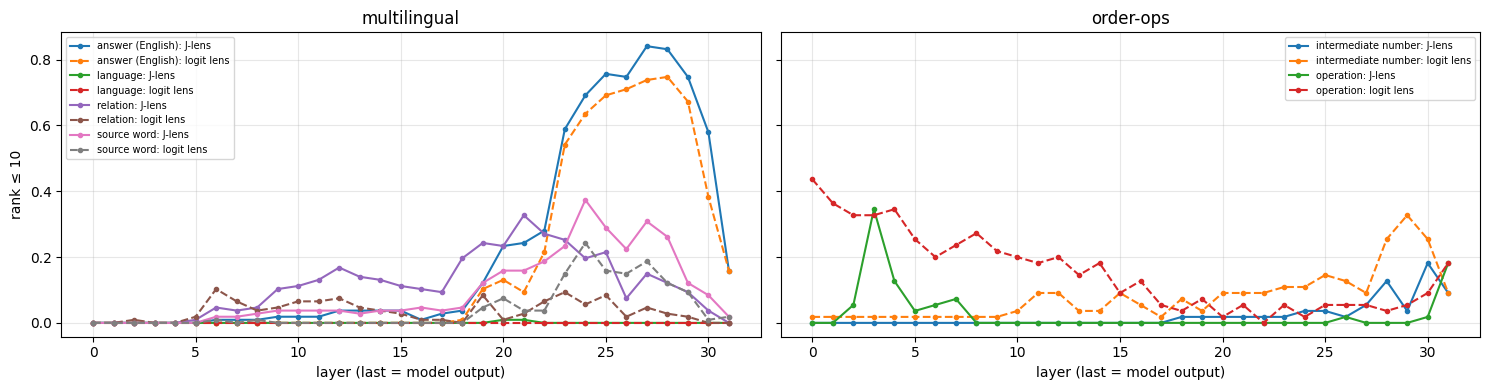

In [28]:
fig, axes = plt.subplots(1, len(ROLE_NAMES), figsize=(15, 4), sharey=True, squeeze=False)
for ax, dataset in zip(axes.flat, ROLE_NAMES):
    group = roles[roles.dataset == dataset]
    for (role, name), role_group in group.groupby(["role_name", "lens"]):
        ax.plot(
            (np.stack(role_group.ranks) <= K).mean(0), marker="o", ms=3,
            label=f"{role}: {name}", linestyle="--" if name == "logit lens" else "-",
        )
    ax.set_title(dataset)
    ax.set_xlabel("layer (last = model output)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
axes.flat[0].set_ylabel(f"rank ≤ {K}")
plt.tight_layout()
plt.show()

### 6d. Does the intermediate show up more often when the model gets the answer right?

In [29]:
correctness = hits.merge(
    with_target[["dataset", "item", "model_correct"]], on=["dataset", "item"], validate="many_to_one"
)
correctness.groupby(["dataset", "model_correct", "lens"]).hit.agg(["mean", "size"]).unstack(["model_correct", "lens"]).round(3)

mean                                size                             
model_correct  False             True              False             True            
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                              
multihop       0.286      0.397  0.625      0.450     63         63     40         40
multilingual   0.487      0.392  0.500      0.393    316        316    112        112
order-ops      0.394      0.543  0.250      0.375     94         94     16         16

## 7. Items: successes and failures

In [30]:
columns = ["dataset", "item", "lens", "word", "best_rank", "best_layer", "inner_best", "inner_best_layer", "in_prompt"]
inter.sort_values("best_rank").groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
3874,typo,typo-together,logit lens,together,1,3,1,3,False
1459,multilingual,slovak-opposite-young,J-lens,young,1,27,1,27,False
1469,multilingual,estonian-opposite-open,logit lens,closed,1,19,1,19,False
1478,multilingual,estonian-opposite-open,J-lens,closed,1,21,1,21,False
1487,multilingual,irish-opposite-big,logit lens,small,1,23,1,23,False
1496,multilingual,irish-opposite-big,J-lens,small,1,23,1,23,False
4154,typo,typo-within,logit lens,within,1,3,1,3,False
3892,typo,typo-around,J-lens,around,1,22,1,22,False
1433,multilingual,croatian-opposite-big,logit lens,small,1,23,1,23,False
3864,typo,typo-science,J-lens,science,1,9,1,9,False


In [31]:
inter.sort_values("best_rank", ascending=False).groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
1878,multilingual,pt-half-six,logit lens,português,43966,31,47839,29,False
1376,multilingual,ukrainian-opposite-day,logit lens,Ukrainian,40416,3,40416,3,False
3770,association,fr-eglise,logit lens,église,39655,29,39655,29,False
3546,association,rivals,logit lens,rivals,38760,31,45289,30,False
2074,multilingual,es-time-after-day,logit lens,español,33599,31,37318,29,False
3432,association,prohibition,J-lens,prohibition,29509,16,29509,16,False
3134,poetry,couplet-time-climb,logit lens,climb,26527,21,26527,21,False
3418,association,divorce,logit lens,divorce,13585,10,13585,10,False
1905,multilingual,pt-double-two,J-lens,português,10026,14,10026,14,False
1743,multilingual,pt-month-after-oct,J-lens,português,10008,6,10008,6,False


What the lens reads at the readout position, layer by layer (first items of each dataset):

In [32]:
readout = items.groupby(["dataset", "lens"]).head(2).set_index(["dataset", "item", "lens"]).readout_top1.apply(pd.Series)
readout.columns.name = "layer"
readout.sort_index()[shown_layers(model.n_layers, LAYER_STRIDE)]

layer                                                    0              2              4              6              8            10           12              14          16          18            20            22          24  \
dataset      item                 lens                                                                                                                                                                                              
association  grief                J-lens                 ….             ….              ‘              —              �            �                           ——      nobody          \n            \n            “I      Nobody   
                                  logit lens                            \n                            用途           什么意思                         翻               翻        什么意思          |^           osz             照      atanya   
             pregnant             J-lens                 ….             ……              ‘              　              ‘            “            “              .“                      \n            .“            ：“          “I   
                                  logit lens                                           \n           avic             au           \n           \n              \n                       Â             ʜ            at     illante   
multihop     amazon-language      J-lens                […]            […]  <|endoftext|>           \n\n           ...\     language    languages            ____   languages   languages     languages     languages        西班牙语   
                                  logit lens                           ...            ...            ...            ...          ...           叫做             ...         ...        ____     languages        called   languages   
             carnival-ocean       J-lens                […]              –  <|endoftext|>          Ocean              …        Ocean        Ocean         Coastal    Maritime     Coastal         Ocean         Ocean    Atlantic   
                                  logit lens                                                           陆              b            �           **              __          __         ___           叫什么           sea    Atlantic   
multilingual french-season-summer J-lens      <|endoftext|>             **             \n             \n           ...'           \n     seasonal          winter      season      winter        winter        winter      autumn   
                                  logit lens                                                           季           less                            <|fim_suffix|>                       վ                      autumn      autumn   
             spanish-opposite-big J-lens      <|endoftext|>            "</           ..."           ..."           ..."          .".           \"            ____        ____        ____          ____          ____       small   
                                  logit lens                             �                             A            ...            …         ____            ____         ___        ____           ___           ...       small   
order-ops    parens-add-mult      J-lens                […]             ……  <|endoftext|>              →  <|endoftext|>           (\           :\              :\          ：“        ____          ____             ？          ?=   
                                  logit lens                                                                                                                              ...         什么呢           تعب             ？           ？   
             parens-sub-mult      J-lens                […]            …..            ...  <|endoftext|>  <|endoftext|>           (\           .\              ……           .          /=          Five             ５         十五条   
                                  logit lens                                                               

The most common readout top-1 tokens per layer over all items — generic tokens mean the lens shows no item-specific content there:

In [33]:
top1_tables = {}
for name in LENS_NAMES:
    top1_by_layer = pd.DataFrame(items[items.lens == name].readout_top1.tolist())
    top1_tables[name] = pd.DataFrame({
        "distinct top-1 / items": top1_by_layer.nunique() / len(top1_by_layer),
        "most common": {
            layer: ", ".join(f"{token!r}×{count}" for token, count in column.value_counts().head(5).items())
            for layer, column in top1_by_layer.items()
        },
    }).rename_axis("layer")
pd.concat(top1_tables, axis=1, names=["lens", "metric"])

lens               logit lens                                                                    J-lens                                                   
metric distinct top-1 / items                                        most common distinct top-1 / items                                        most common
layer                                                                                                                                                     
0                    0.023593  ' '×483, '<|endoftext|>'×27, '-'×22, '/'×4, '....               0.061706  ' […]'×148, '….'×111, '.–'×105, '<|endoftext|>...
1                    0.105263         ' '×332, '...'×90, '-'×18, ' "'×16, ','×11               0.108893  '<|endoftext|>'×154, '….'×73, ' […]'×58, '..."...
2                    0.228675        ' '×158, '...'×79, ' "'×48, '\n'×41, '-'×33               0.139746  ' […]'×110, '……'×59, '<|endoftext|>'×58, '….'×...
3                    0.190563        ' '×253, '...'×84, '\n'×38, ' "'×35, '-'×25               0.152450     'ly'×99, ' ——'×68, ' ='×44, ' "'×44, ' ...'×27
4                    0.185118        ' '×203, '...'×114, '\n'×71, '"'×20, '-'×13               0.143376  '<|endoftext|>'×129, 'ly'×69, '..."'×65, ' ......
5                    0.181488        ' '×173, '...'×159, '\n'×47, '"'×21, "'"×12               0.143376  '<|endoftext|>'×76, '......'×74, '..."'×72, '\...
6                    0.272232         '...'×155, ' '×93, '\n'×39, '…'×22, 'I'×11               0.170599  '..."'×59, '......'×55, '<|endoftext|>'×48, '—...
7                    0.259528        '...'×140, ' '×109, '\n'×47, '…'×33, '�'×12               0.161525  '“'×113, '..."'×61, ' ...\\'×33, '——'×27, '<|e...
8                    0.274047        ' '×105, '...'×103, '…'×31, '\n'×27, '一'×21               0.199637  '“'×77, '..."'×57, '——'×50, '<|endoftext|>'×46...
9                    0.243194          ' '×120, 'ly'×46, '\n'×40, '-'×38, '…'×29               0.243194  '.“'×59, '“'×37, '——'×33, '..."'×30, '<|endoft...
10                   0.217786         ' '×124, '...'×64, '('×56, '\n'×45, '…'×38               0.241379       '.“'×95, '“'×36, '——'×35, '\\"'×31, '.".'×25
11                   0.243194        '...'×122, ' '×100, '…'×42, '\n'×29, '�'×20               0.246824       '“'×114, '\\"'×47, '�'×37, ':\\'×27, '——'×20
12                   0.270417          ' '×94, '�'×62, '...'×54, '倒'×33, '\n'×31               0.246824     '\\"'×56, '.“'×54, '“'×43, '\xa0'×31, ':\\'×29
13                   0.203267      '...'×125, ' '×96, '�'×64, '____'×29, '\n'×28               0.241379    '“'×86, '\\"'×55, '\xa0'×29, '——'×26, '____'×14
14                   0.186933       '...'×180, ' '×92, '____'×52, '�'×35, '…'×24               0.194192     '...'×81, '——'×47, '____'×43, '\\"'×41, '.'×20
15                   0.206897       '...'×155, ' '×74, '____'×52, '�'×31, '…'×24               0.188748     '\xa0'×85, '.'×65, '\\"'×63, '____'×44, ';'×23
16                   0.230490       '...'×149, '____'×70, ' '×54, '�'×30, '…'×27               0.212341   '...'×82, '____'×71, '\\"'×48, '.'×46, '\xa0'×28
17                   0.286751   '____'×85, '...'×63, '\u200b'×34, '�'×32, ' '×29               0.199637  '____'×124, '\xa0'×61, '.'×49, '\\"'×43, '...'×31
18                   0.274047   '____'×99, '...'×57, '�'×30, '\ufeff'×30, ' '×22               0.203267   '____'×131, '\xa0'×53, '\\"'×42, '.'×37, '\n'×27
19                   0.460980  '...'×38, '____'×35, '\u3000\u3000'×25, '…'×18...               0.214156  '____'×111, '.'×47, '\xa0'×30, '\n'×27, ' They...
20                   0.480944  '____'×43, '___'×35, '\xa0\xa0\xa0\xa0\xa0\xa0...               0.270417  '____'×148, '.'×24, '.“'×17, '\xa0'×15, ' Mont...
21                   0.495463  '\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0'×39, '___'×3...               0.301270  '____'×121, '.'×27, ' But'×20, '/='×19, ' And'×16
22                   0.464610  '...'×63, '？'×32, '�'×18, 'at'×18, '\xa0\xa0\x...               0.419238   '____'×59, '？'×19, 

### 7a. Paired inner-layer ranks: which lens improves each intermediate?

One row per intermediate occurrence, aligned by dataset, item, word, and role. A positive
`log10 gain` means J-lens lowers the best inner-layer rank; ties are counted explicitly.

In [34]:
head_to_head = inter.pivot(
    index=["dataset", "item", "word", "role"], columns="lens", values="inner_best"
)
head_to_head["winner"] = np.select(
    [head_to_head["J-lens"] < head_to_head["logit lens"],
     head_to_head["J-lens"] > head_to_head["logit lens"]],
    ["J-lens", "logit lens"], default="tie",
)
head_to_head["log10 gain"] = np.log10(head_to_head["logit lens"]) - np.log10(head_to_head["J-lens"])
paired_summary = head_to_head.groupby("dataset").winner.value_counts().unstack(fill_value=0)
paired_summary = paired_summary.reindex(columns=["J-lens", "logit lens", "tie"], fill_value=0)
paired_summary["median log10 gain"] = head_to_head.groupby("dataset")["log10 gain"].median()
display(paired_summary.round(3))
display(head_to_head.sort_values("log10 gain", ascending=False).head(15))
display(head_to_head.sort_values("log10 gain").head(15))

winner,J-lens,logit lens,tie,median log10 gain
dataset,,,,
association,78,24,0,0.419
multihop,44,47,12,0.000
multilingual,280,75,73,0.301
order-ops,25,79,6,-0.382
poetry,83,15,0,0.427
typo,35,48,13,-0.021


lens                                                 J-lens  logit lens  winner  log10 gain
dataset      item                    word      role                                        
multilingual norwegian-season-spring Norwegian 0          7        5110  J-lens    2.863323
typo         typo-football           football  0          1         523  J-lens    2.718502
multilingual de-month-after-jul      German    0         16        6861  J-lens    2.632267
typo         typo-college            college   0          1         340  J-lens    2.531479
association  lonely                  lonely    0         45       10671  J-lens    2.374993
multilingual norwegian-season-spring season    1          1         234  J-lens    2.369216
             de-month-after-jan      German    0         33        7635  J-lens    2.364295
typo         typo-really             really    0          4         628  J-lens    2.195900
multilingual de-time-after-night     German    0         31        4172  J-lens    2.128983
             spanish-number-three    Spanish   0         43        5285  J-lens    2.089577
             es-month-before-jun     español   0        710       85581  J-lens    2.081119
             finnish-season-summer   Finnish   0         21        2351  J-lens    2.049033
             danish-color-ocean      Danish    0         89        9827  J-lens    2.043031
             es-month-after-mar      español   0        454       48967  J-lens    2.032848
             de-month-before-dec     German    0         74        6806  J-lens    1.963660

lens                                                  J-lens  logit lens      winner  log10 gain
dataset      item                      word     role                                            
multihop     nhop-chess-element        16       0        995           1  logit lens   -2.997823
             nhop-suit-element         13       0        771           1  logit lens   -2.887054
             nhop-deck-element         52       0        562           1  logit lens   -2.749736
             nhop-fortnight-element    14       0        509           1  logit lens   -2.706718
             nhop-clock-element        12       0        458           1  logit lens   -2.660865
             nhop-alphabet-element     26       0        425           1  logit lens   -2.628389
             nhop-soccer-element       11       0        324           1  logit lens   -2.510545
typo         typo-support              support  0        300           1  logit lens   -2.477121
             typo-account              account  0        596           2  logit lens   -2.474216
             typo-number               number   0        247           1  logit lens   -2.392697
             typo-since                since    0        237           1  logit lens   -2.374748
             typo-together             together 0        213           1  logit lens   -2.328380
multilingual turkish-opposite-fast     opposite 1       3857          26  logit lens   -2.171276
             vietnamese-opposite-heavy opposite 1        122           1  logit lens   -2.086360
             german-opposite-loud      opposite 1        237           2  logit lens   -2.073718

## 8. Adaptations of reference Figures 52, 55, and 56

These reproduce **plot forms, not the reference experiment**: the loaded generic model/J-lens
and local evaluation sets are not the reference model or necessarily its sample subsets.
The original exact sample subsets and symmetric-KL normalization are unknown. There is
**no tuned lens** and no Sonnet workspace shading. See `docs/reference_plots.md` and
`docs/lens_metrics.md` for shared definitions and limitations.

### 8a. Figure 52: intermediate hit rate versus k (no new inference)
Only annotated **single-token intermediates** are included; first-token fallbacks are excluded.
For each k, take each word's best rank over **all blocks, including the shared final output**,
average word hits within an item, then average items. Items with no retained words are omitted,
not failures. Counts disclose exclusions **per lens** (paired annotations are repeated).
Tokenization/accepted spelling variants are this evaluator's, not a guaranteed reference match.
Cached ranks inherit `evaluate_paired()`'s `prompt.rstrip()` before tokenization: trailing
whitespace is removed, potentially changing tokenization and the final-token readout position.
This is not a whitespace-exact reproduction; established evaluation semantics are unchanged.

Legends report trapezoidal AUC versus **log(k)** normalized by log(100/1), on k = 1, 2, 5, 10,
20, 50, 100. AUC/hit rates range from 0 to 1. Black = J-lens; red = logit lens.

,dataset,lens,n_words_total,n_words_used,n_words_excluded,n_items_total,n_items_used,n_items_excluded
0,association,J-lens,102,102,0,102,102,0
1,association,logit lens,102,102,0,102,102,0
2,multihop,J-lens,103,94,9,93,84,9
3,multihop,logit lens,103,94,9,93,84,9
4,multilingual,J-lens,428,426,2,107,107,0
5,multilingual,logit lens,428,426,2,107,107,0
6,order-ops,J-lens,110,109,1,55,55,0
7,order-ops,logit lens,110,109,1,55,55,0
8,poetry,J-lens,98,98,0,98,98,0
9,poetry,logit lens,98,98,0,98,98,0


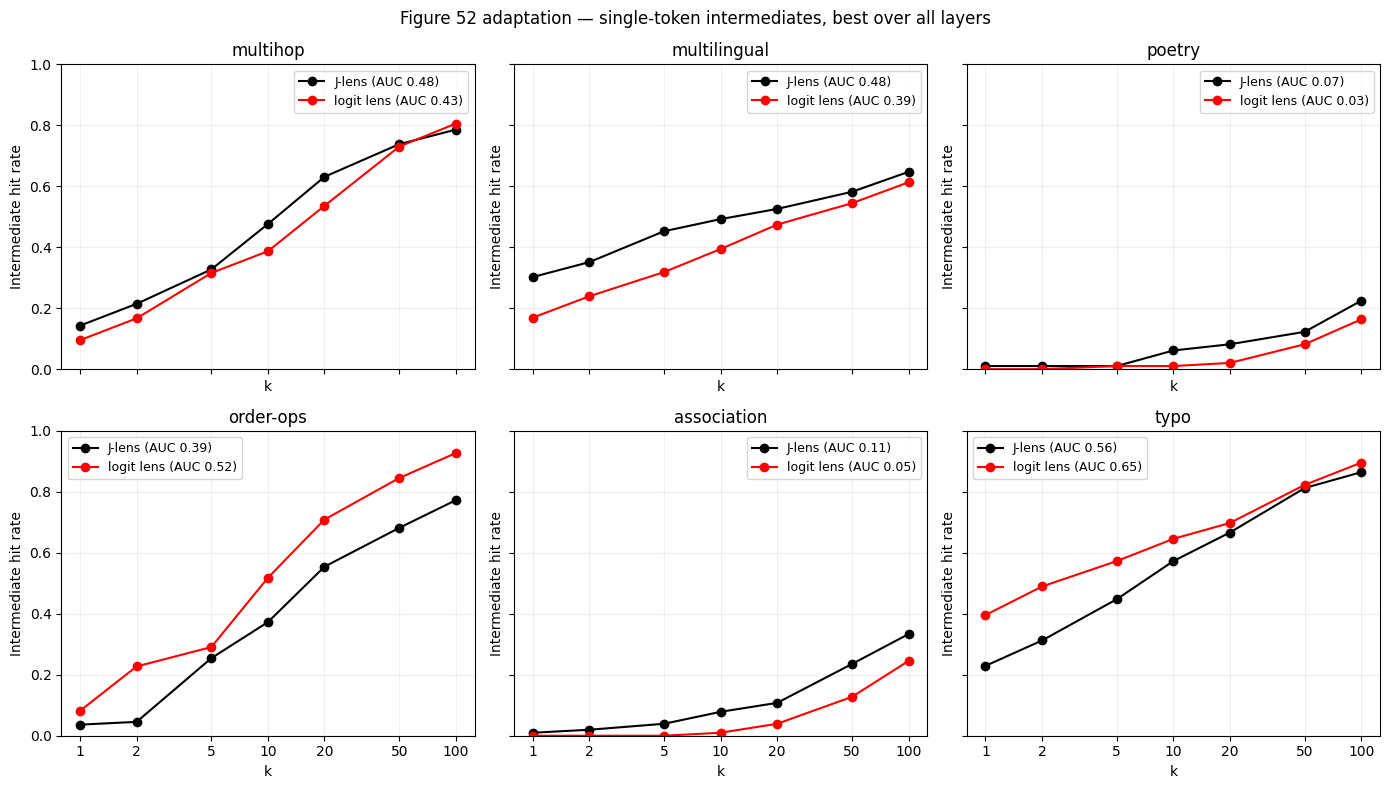

In [35]:
from jlens.reference_plots import (
    intermediate_rank_sweep, plot_intermediate_sweep,
    plot_distribution_summary, plot_lens_comparison,
)

reference52 = intermediate_rank_sweep(words)
display(reference52.counts)
fig52, axes52 = plot_intermediate_sweep(reference52)
plt.show()

### 8b. Figures 55/56: explicitly supplied held-out text (opt-in extra evaluation)
**No refit is needed.** These distribution metrics cannot be recovered from `words`/`items`;
they require new forwards with the already loaded model/lens. Default is **disabled**. Supply
independent texts below (not the fitting corpus or task prompts) and name their source.
No downloads or automatic corpus substitution occur. Small samples are diagnostics, not
reproductions of pretraining-distribution results. Record selection and fitting provenance.

All actual model blocks are evaluated. Depth = 100 * block_index / (n_blocks - 1): first
block output 0, shared final output 100; no embedding row. Means weight every non-special
input position equally, including each text's last position, after per-text truncation.
Longer texts contribute more tokens. Natural-log KL and entropy are in **nats**.

* **55:** KL(model || lens), lens entropy, top-1 agreement with model **in percent**.
  J-lens blue, logit lens purple.
* **56:** one purple J/logit comparison at each **same layer**: vocabulary-vector cosine,
  **0.5 * (KL(J || logit) + KL(logit || J))**, and top-1 agreement **as a fraction**.
  The half-sum is explicit; original normalization unknown. Cross-layer pairs are never averaged.
* Cosine compares corresponding rows of W_U and W_U @ J, averaged equally over nonzero
  vocabulary-vector pairs. This **linear-head-only geometry** excludes bias, final normalization,
  and softcap; it is not exact global geometry for a nonlinear decoder. Unsupported output
  heads/adapters are labeled **unavailable, not zero** in the status/counts table. Distributions
  still use `model.unembed`, including its normalization, output head, and any softcap.
  The cosine axis is **0 to 1** for nonnegative/unavailable values; any displayed negative value
  extends it to **-1 to 1**, disclosed in the title. Negative cosines are never silently clipped.

Start with a few short texts: all-layer readouts may be expensive for large models/vocabularies.
Position chunks bound vocabulary-distribution memory, not activation/Jacobian memory. Reduce
chunk size or sequence length if needed. Evaluation and plotting are separate so cached tables
can be replotted without extra forwards.

In [36]:
# Opt in here; keep this sample independent of lens fitting.
HELD_OUT_TEXTS = None  # a nonempty list[str] of held-out passages
HELD_OUT_SOURCE = ''  # corpus/version, split, sample selection
# Local-file example: one independently held-out passage per nonempty line.
# HELD_OUT_TEXTS = [s for s in Path('/path/to/heldout.txt').read_text().splitlines() if s.strip()]
# HELD_OUT_SOURCE = 'my-corpus v1, held-out split, first 8 passages (disjoint from fitting)'
HELD_OUT_MAX_SEQ_LEN = 128
HELD_OUT_POSITION_CHUNK_SIZE = 4
GEOMETRY_VOCAB_CHUNK_SIZE = 1024

In [37]:
# Clear cached results first so disabled/failed reruns cannot plot stale metrics.
held_out_metrics = held_out_geometry = held_out_run = None
if HELD_OUT_TEXTS is None:
    print('Figures 55/56 skipped: supply independent HELD_OUT_TEXTS and HELD_OUT_SOURCE above. No downloads or extra evaluation run.')
else:
    if not isinstance(HELD_OUT_TEXTS, (list, tuple)) or not HELD_OUT_TEXTS:
        raise ValueError('Supply a nonempty list/tuple of independently held-out strings.')
    if not all(isinstance(text, str) and text.strip() for text in HELD_OUT_TEXTS):
        raise ValueError('Every held-out passage must be a nonempty string.')
    if not isinstance(HELD_OUT_SOURCE, str) or not HELD_OUT_SOURCE.strip():
        raise ValueError('Describe the independent sample in HELD_OUT_SOURCE first.')
    from jlens.metrics import evaluate_distributions, lens_vector_geometry

    held_out_run = {
        'model': globals().get('MODEL_ID', type(model).__name__),
        'model_dtype': str(next(model.layers[0].parameters()).dtype),
        'device': str(model.input_device),
        'source': HELD_OUT_SOURCE, 'n_texts_supplied': len(HELD_OUT_TEXTS),
        'max_seq_len': HELD_OUT_MAX_SEQ_LEN,
        'position_chunk_size': HELD_OUT_POSITION_CHUNK_SIZE,
        'layers': 'all blocks, shared final output', 'weighting': 'token',
        'float32_matmul_precision': torch.get_float32_matmul_precision(),
    }
    display(held_out_run)
    held_out_metrics = evaluate_distributions(
        model, fitted_lens, HELD_OUT_TEXTS, layers=None,
        max_seq_len=HELD_OUT_MAX_SEQ_LEN,
        position_chunk_size=HELD_OUT_POSITION_CHUNK_SIZE, pairwise=True,
    )
    held_out_geometry = lens_vector_geometry(
        model, fitted_lens, layers=None, vocab_chunk_size=GEOMETRY_VOCAB_CHUNK_SIZE,
    )
    display(held_out_metrics.layers)
    display(held_out_geometry)

Figures 55/56 skipped: supply independent HELD_OUT_TEXTS and HELD_OUT_SOURCE above. No downloads or extra evaluation run.


In [38]:
fig55 = axes55 = fig56 = axes56 = None
if held_out_metrics is None or held_out_geometry is None:
    print('No held-out figures to plot. Configure the sample and run the evaluation cell first.')
else:
    print('Held-out sample:', held_out_run['source'])
    fig55, axes55 = plot_distribution_summary(held_out_metrics.layers, n_layers=model.n_layers)
    plt.show()
    fig56, axes56 = plot_lens_comparison(
        held_out_metrics.pairs, held_out_geometry, n_layers=model.n_layers,
    )
    plt.show()

No held-out figures to plot. Configure the sample and run the evaluation cell first.


## 9. Conclusions

The cell below turns the numbers above into statements, so they stay correct after a re-run
(other seed, other `K`, other model size).

In [39]:
def pct(x):
    return "n/a" if x is None or pd.isna(x) else f"{100 * x:.0f}%"


def layer(x):
    return "never" if x is None else f"L{x}"


def hit_rates(frame, column):
    """Hit rate (best rank <= K) split by a boolean column: {value: (rate, n)}."""
    hit = (frame.best_rank <= K).groupby(frame[column])
    return {value: (rate, n) for value, rate, n in zip(hit.mean().index, hit.mean(), hit.size())}

In [40]:
lines = ["Model accuracy (top-1 == target): " + ", ".join(f"{d} {pct(a)}" for d, a in accuracy.items()) + "."]
for name in LENS_NAMES:
    lines.append(f"--- {name} ---")
    lens_at_k = at_k.xs(name, axis=1, level="lens")
    inner_lens_at_k = inner_at_k.xs(name, axis=1, level="lens")
    output_lens_at_k = output_at_k.xs(name, axis=1, level="lens")
    lens_inter = inter[inter.lens == name]
    inter_curve = layer_hit_rate(lens_inter, K)
    target_curve = layer_hit_rate(target[target.lens == name], K)
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    lens_roles = roles[roles.lens == name]
    lens_correctness = correctness[correctness.lens == name]
    for dataset in lens_at_k.index:
        i, c = lens_at_k.loc[dataset, "intermediate"], lens_at_k.loc[dataset].get("control")
        verdict = "clearly above" if i >= c + 0.1 else "slightly above" if i > c else "NOT above"
        peak = inter_curve.loc[dataset].iloc[:-1]
        lines.append(
            f"{dataset}: intermediates pass@{K} {pct(i)} vs control {pct(c)} — {verdict} chance; "
            f"inner layers alone {pct(inner_lens_at_k.loc[dataset, 'intermediate'])}, model output alone "
            f"{pct(output_lens_at_k.loc[dataset, 'intermediate'])}; best inner layer L{peak.idxmax()} "
            f"({pct(peak.max())} of words at rank ≤ {K})."
        )

    for dataset in target_curve.index:
        curve = target_curve.loc[dataset]
        if curve.iloc[-1] == 0:
            lines.append(f"{dataset}: the target is never in the output top-{K}.")
        else:
            lines.append(
                f"{dataset}: the target is in the output top-{K} for {pct(curve.iloc[-1])} of items "
                f"and reaches half of that by {layer(first_layer(curve, curve.iloc[-1] / 2))}."
            )

    for dataset in agreement.index:
        lines.append(
            f"{dataset}: lens top-1 == model top-1 on ≥50% of positions from {layer(first_layer(agreement.loc[dataset], 0.5))}, "
            f"KL ≤ 1 nat from {layer(first_layer(kl.loc[dataset], 1.0, above=False))}; copy rate "
            f"{pct(copy_rate.loc[dataset, 0])} at L0 → {pct(copy_rate.loc[dataset, LAST - 1])} at L{LAST - 1}."
        )

    for column, yes, no in [
        ("in_prompt", "already in the prompt", "absent from it"),
        ("single_token", "single-token", "first-token fallback"),
    ]:
        rates = hit_rates(lens_inter, column)
        (r_yes, n_yes), (r_no, n_no) = rates.get(True, (None, 0)), rates.get(False, (None, 0))
        lines.append(f"Intermediates {yes}: hit rate {pct(r_yes)} (n={n_yes}) vs {pct(r_no)} (n={n_no}) {no}.")

    for dataset, group in lens_roles.groupby("dataset"):
        by_role = group.groupby("role_name").hit.mean().sort_values(ascending=False)
        lines.append(f"{dataset} by role: " + ", ".join(f"{name} {pct(rate)}" for name, rate in by_role.items()) + ".")

    by_correct = lens_correctness.groupby("model_correct").hit.mean()
    lines.append(
        f"Intermediate hit rate when the model is right: {pct(by_correct.get(True))}, when wrong: {pct(by_correct.get(False))}."
    )


for dataset in inner_at_k.index:
    row = inner_at_k.loc[dataset]
    j, l = row[("intermediate", "J-lens")], row[("intermediate", "logit lens")]
    jc, lc = row[("control", "J-lens")], row[("control", "logit lens")]
    lines.append(
        f"{dataset}: inner-layer pass@{K}, J-lens {pct(j)} vs logit lens {pct(l)} "
        f"(Δ {100 * (j - l):+.1f} pp); margins over control "
        f"{100 * (j - jc):+.1f} pp vs {100 * (l - lc):+.1f} pp."
    )
for dataset, row in paired_summary.iterrows():
    lines.append(
        f"{dataset}: J-lens ranks intermediates higher in {row.get('J-lens', 0):.0f} cases, "
        f"logit lens in {row.get('logit lens', 0):.0f}, ties {row.get('tie', 0):.0f}; "
        f"median log10 rank gain {row['median log10 gain']:+.2f}."
    )
for line in lines:
    print("•", line)

• Model accuracy (top-1 == target): multihop 40%, multilingual 26%, order-ops 15%.
• --- logit lens ---
• association: intermediates pass@10 1% vs control 0% — slightly above chance; inner layers alone 1%, model output alone 0%; best inner layer L29 (1% of words at rank ≤ 10).
• multihop: intermediates pass@10 45% vs control 17% — clearly above chance; inner layers alone 44%, model output alone 30%; best inner layer L30 (25% of words at rank ≤ 10).
• multilingual: intermediates pass@10 39% vs control 0% — clearly above chance; inner layers alone 39%, model output alone 4%; best inner layer L27 (24% of words at rank ≤ 10).
• order-ops: intermediates pass@10 52% vs control 38% — clearly above chance; inner layers alone 52%, model output alone 14%; best inner layer L0 (23% of words at rank ≤ 10).
• poetry: intermediates pass@10 1% vs control 0% — slightly above chance; inner layers alone 1%, model output alone 0%; best inner layer L19 (1% of words at rank ≤ 10).
• typo: intermediates pass

### How to read these numbers

* **Intermediates vs control.** Compare each lens with its control baseline and compare the
  margins between lenses. A larger raw hit rate alone does not establish better intermediate readout.
* **Inner layers vs model output.** Both lenses use the exact same model output. All-layer
  metrics preserve the original analysis; inner-layer pass@k and the paired ranks isolate
  differences in the lens. An inner-layer hit is suggestive, not proof of a reasoning step.
* **Copy rate.** High early-layer copy rates can explain hits for words already in the prompt.
  Compare both lenses' copy curves and the in-prompt split (§6a).
* **Agreement / KL.** Earlier agreement and lower KL describe fidelity to the model output;
  they do not by themselves show that intermediates are exposed better.
* **Model correctness.** Accuracy is measured once per item. The right/wrong split keeps
  both lens measurements attached to that same model answer.
* **Tokenization.** Multi-token words fall back to their first token, which can be generic.
  The single-token split (§6b) retains this diagnostic. Controls share the dataset topic.
* **Fit corpus.** A J-lens depends on its fitting corpus and selected model. Use an independent
  corpus, keep the checkpoint with its model, and vary the mix to test sensitivity.